<a href="https://colab.research.google.com/github/cheecaixi/AISDPJ/blob/main/AISDPJ_Cleaning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Load Data
2. Remove Duplicates
3. Handle Missing Values
4. Fix Invalid Values
5. Standardize Categories
6. Correct Data Types
7. Detect and Handle Outliers
8. Encode Categorical Features
9. Scale Numerical Features
10. Feature Engineering
11. Final Validation

# **1. Load Data**

In [85]:
# Import Libraries
import sqlite3
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [86]:
# Load the dataset from the CSV file
CSV_PATH = "/content/gas_monitoring_eda.csv"
df = pd.read_csv(CSV_PATH)

In [87]:
display(df)

,Time of Day,Temperature,Humidity,CO2_InfraredSensor,CO2_ElectroChemicalSensor,MetalOxideSensor_Unit1,MetalOxideSensor_Unit2,MetalOxideSensor_Unit3,MetalOxideSensor_Unit4,CO_GasSensor,Session ID,HVAC Operation Mode,Ambient Light Level,Activity Level,CO2_Disagreement,MOS_Mean,Ambient_Light_Ordinal,Is_Night,Activity_Encoded
0,morning,19.63,53.83,125.486389,571.089440,478.554958,735.850412,654.625253,565.051969,2.0,7241,off,very_dim,Low Activity,445.603052,608.520648,1.0,0,0
1,morning,292.81,53.69,126.343018,575.789501,491.955151,740.282738,655.734327,557.078486,1.0,7241,ventilation_only,bright,Low Activity,449.446484,611.262675,4.0,0,0
2,morning,19.62,54.25,126.560695,585.543111,505.560808,737.112906,649.962421,558.065196,1.0,7241,eco_mode,NaN,Low Activity,458.982416,612.675333,NaN,0,0
3,morning,20.10,50.48,113.504877,597.449961,515.142272,744.020651,676.150075,600.222210,NaN,7241,eco_mode,very_bright,High Activity,483.945084,633.883802,5.0,0,2
4,morning,19.89,48.42,92.766225,613.654875,535.664558,770.265441,720.274019,625.731124,1.0,7241,heating_active,moderate,Low Activity,520.888650,662.983785,3.0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,evening,23.45,NaN,137.854649,544.124855,510.926349,NaN,680.916215,620.292682,1.0,2586,maintenance_mode,very_bright,Low Activity,406.270206,604.045082,5.0,0,0
9996,evening,297.24,46.98,131.945968,541.756022,517.719693,738.901193,689.383365,625.100827,2.0,2586,ventilation_only,very_dim,Low Activity,409.810054,642.776270,1.0,0,0
9997,evening,23.71,49.16,136.422868,542.072190,512.607291,732.456099,683.197988,622.035384,2.0,2586,eco_mode,very_bright,Low Activity,405.649322,637.574191,5.0,0,0
9998,night,20.58,NaN,126.734430,561.716292,435.638480,707.447312,648.634308,581.583550,1.0,4761,cooling_active,very_bright,Low Activity,434.981862,593.325913,5.0,1,0


In [88]:
# The inital Shape of the dataset before cleaning
print(df.shape)

(10000, 19)


In [89]:
print("\nDataset Summary:")

# Re-identify numerical and categorical columns after cleaning
numerical_cols = df.select_dtypes(include=np.number).columns
categorical_cols = df.select_dtypes(include='object').columns

summary = pd.DataFrame({
    'Dtype': df.dtypes,
    'Non-Null Count': df.count(),
    'Missing Values': df.isnull().sum()
})

summary['Column Type'] = 'Other'
summary.loc[numerical_cols, 'Column Type'] = 'Numerical'
summary.loc[categorical_cols, 'Column Type'] = 'Categorical'

# Drop the 'Dtype' column as requested
summary = summary.drop(columns=['Dtype'])

display(summary)


Dataset Summary:


,Non-Null Count,Missing Values,Column Type
Time of Day,10000,0,Categorical
Temperature,10000,0,Numerical
Humidity,8072,1928,Numerical
CO2_InfraredSensor,10000,0,Numerical
CO2_ElectroChemicalSensor,10000,0,Numerical
MetalOxideSensor_Unit1,10000,0,Numerical
MetalOxideSensor_Unit2,8590,1410,Numerical
MetalOxideSensor_Unit3,10000,0,Numerical
MetalOxideSensor_Unit4,10000,0,Numerical
CO_GasSensor,9166,834,Numerical


Displayed a summary table of the dataset, showing each column's non-null count, missing values, and column type.

The dataset contains 10,000 records with a mix of categorical and numerical features related to environmental and sensor data.

Most columns are complete with no missing values, indicating generally good data quality.

However, several attributes such as
- Humidity (1,928 missing values)
- MetalOxideSensor_Unit2 (1,410 missing values)
- Ambient Light Level (1,054 missing values)
- CO_GasSensor (834 missing values)
- Ambient_Light_Ordinal (1054 missing values)

require data cleaning or handling before analysis.

The dataset also includes engineered features like CO2_Disagreement, MOS_Mean, Is_Night, and Activity_Encoded, which may help improve predictive analysis and pattern detection.

# **2. Remove Duplicates**

In [90]:
# Remove duplicate rows
duplicate_count = df.duplicated().sum()
print(f"\nDuplicate Rows Found: {duplicate_count}")

df = df.drop_duplicates()
print(f"Shape After Removing Duplicates: {df.shape}")


Duplicate Rows Found: 265
Shape After Removing Duplicates: (9735, 19)


Removing duplicates helps improve data accuracy and prevents repeated records from affecting the reliability of the analysis and model results.

# **3. Handle Missing Values & Fix Invalid Values**

In [91]:
print(f"\nMissing values: {df.isnull().sum().sum()}")


Missing values: 6242


In [92]:
# Overview of missing values
missing_counts = df.isnull().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_pct.round(2)
}).query("`Missing Count` > 0")

print("Missing Values Summary:")
print(missing_summary)

Missing Values Summary:
                        Missing Count  Missing %
Humidity                         1911      19.63
MetalOxideSensor_Unit2           1402      14.40
CO_GasSensor                      829       8.52
Ambient Light Level              1050      10.79
Ambient_Light_Ordinal            1050      10.79


Which columns has missing values, and the percentage of the missing values

In [93]:
# Understand data distribution before choosing imputation methods
columns_with_missing = [
    "Humidity",
    "MetalOxideSensor_Unit2",
    "CO_GasSensor"
]

print("\nStatistics for Columns with Missing Values:")
print(
    df[columns_with_missing]
    .agg(["mean", "median", "std", "min", "max"])
    .round(4)
)


Statistics for Columns with Missing Values:
        Humidity  MetalOxideSensor_Unit2  CO_GasSensor
mean     51.6662                728.4089        1.2883
median   51.3900                726.7845        1.0000
std      21.6576                 29.1548        0.7790
min     -49.8700                611.1689        0.0000
max     198.9000                807.7329        4.0000


Understanding the distribution of numerical features and determine whether median or mean imputation is more suitable.

In [94]:
# Remove physically impossible sensor readings
before = df.shape[0]

df = df[(df["Humidity"] >= 0) & (df["Humidity"] <= 100)]
df = df[(df["Temperature"] >= -20) & (df["Temperature"] <= 60)]
df = df[df["CO2_InfraredSensor"] >= 0]
df = df[df["CO_GasSensor"] >= 0]

rows_removed = before - df.shape[0]

print(f"\nRows removed due to invalid sensor values: {rows_removed}")
print(f"Dataset shape after cleaning: {df.shape}")


Rows removed due to invalid sensor values: 3576
Dataset shape after cleaning: (6159, 19)


Remove physically impossible sensor readings that may reduce data quality and negatively affect model performance.

In [95]:
# Median imputation for numerical sensor data
num_impute_cols = [
    "Humidity",
    "MetalOxideSensor_Unit2",
    "CO_GasSensor"
]

for col in num_impute_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

    print(f"{col:<30} imputed using median: {median_val:.4f}")

Humidity                       imputed using median: 51.4200
MetalOxideSensor_Unit2         imputed using median: 726.8521
CO_GasSensor                   imputed using median: 1.0000


Replace missing numerical sensor values using the median, which is more robust against skewed data and outliers.

In [96]:
# Maintain consistency between categorical and ordinal columns

ambient_mode_label = df["Ambient Light Level"].mode()[0]

ambient_mode_ordinal = (
    df.loc[
        df["Ambient Light Level"] == ambient_mode_label,
        "Ambient_Light_Ordinal"
    ]
    .mode()[0]
)

# Fill missing rows consistently
missing_ambient = df["Ambient Light Level"].isna()
df.loc[missing_ambient, "Ambient Light Level"] = ambient_mode_label
df.loc[missing_ambient, "Ambient_Light_Ordinal"] = ambient_mode_ordinal

print(f"{'Ambient Light Level':<30} mode: '{ambient_mode_label}'")
print(f"{'Ambient_Light_Ordinal':<30} synced ordinal: {ambient_mode_ordinal}")

Ambient Light Level            mode: 'very_bright'
Ambient_Light_Ordinal          synced ordinal: 5.0


Fill missing categorical values while maintaining consistency between categorical labels and ordinal encoded values.

In [97]:
# Final validation
print("\nRemaining Missing Values:")
print(df.isnull().sum())

print(f"\nTotal Remaining Missing Values: {df.isnull().sum().sum()}")


Remaining Missing Values:
Time of Day                  0
Temperature                  0
Humidity                     0
CO2_InfraredSensor           0
CO2_ElectroChemicalSensor    0
MetalOxideSensor_Unit1       0
MetalOxideSensor_Unit2       0
MetalOxideSensor_Unit3       0
MetalOxideSensor_Unit4       0
CO_GasSensor                 0
Session ID                   0
HVAC Operation Mode          0
Ambient Light Level          0
Activity Level               0
CO2_Disagreement             0
MOS_Mean                     0
Ambient_Light_Ordinal        0
Is_Night                     0
Activity_Encoded             0
dtype: int64

Total Remaining Missing Values: 0


Median imputation was selected because several sensor related features showed potential skewness and outlier presence. Invalid sensor readings were removed before imputation to improve overall data reliability. After preprocessing, all missing values were successfully handled and the dataset became more suitable for machine learning preparation.

# **4. Standardize Categories**

In [98]:
# Strip whitespace and unify text format across all categorical columns

categorical_columns = ["Time of Day", "HVAC Operation Mode", "Ambient Light Level", "Activity Level"]

# Before standardisation - check current unique values
print("Unique values BEFORE standardisation:")
for col in categorical_columns:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

for col in categorical_columns:
    df[col] = df[col].astype(str).str.strip().str.lower()

# After standardisation - confirm values are clean
print("\nUnique values AFTER standardisation:")
for col in categorical_columns:
    print(f"  {col}: {sorted(df[col].unique())}")

Unique values BEFORE standardisation:
  Time of Day: ['afternoon', 'evening', 'morning', 'night']
  HVAC Operation Mode: ['cooling_active', 'eco_mode', 'heating_active', 'maintenance_mode', 'off', 'ventilation_only']
  Ambient Light Level: ['bright', 'dim', 'moderate', 'very_bright', 'very_dim']
  Activity Level: ['High Activity', 'Low Activity', 'Moderate Activity']

Unique values AFTER standardisation:
  Time of Day: ['afternoon', 'evening', 'morning', 'night']
  HVAC Operation Mode: ['cooling_active', 'eco_mode', 'heating_active', 'maintenance_mode', 'off', 'ventilation_only']
  Ambient Light Level: ['bright', 'dim', 'moderate', 'very_bright', 'very_dim']
  Activity Level: ['high activity', 'low activity', 'moderate activity']


Categorical values were standardized to ensure consistency across the dataset. Text formatting differences such as capitalization and extra spaces were removed to prevent duplicate category representations during encoding and analysis.

# **5. Correct Data Types**

In [99]:
# Record dtypes BEFORE correction for comparison
dtypes_before = df.dtypes.copy()
memory_before = df.memory_usage(deep=True).sum()

print("Data types BEFORE correction:")
print(dtypes_before)

Data types BEFORE correction:
Time of Day                   object
Temperature                  float64
Humidity                     float64
CO2_InfraredSensor           float64
CO2_ElectroChemicalSensor    float64
MetalOxideSensor_Unit1       float64
MetalOxideSensor_Unit2       float64
MetalOxideSensor_Unit3       float64
MetalOxideSensor_Unit4       float64
CO_GasSensor                 float64
Session ID                     int64
HVAC Operation Mode           object
Ambient Light Level           object
Activity Level                object
CO2_Disagreement             float64
MOS_Mean                     float64
Ambient_Light_Ordinal        float64
Is_Night                       int64
Activity_Encoded               int64
dtype: object


In [100]:
# Convert sensor and numerical columns to numeric format
float_columns = [
    "Temperature", "Humidity", "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor", "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2", "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4", "CO_GasSensor"
]

for col in float_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Session ID is treated as an identifier rather than a numerical feature
df["Session ID"] = df["Session ID"].astype(str)

# Convert categorical text features to category dtype
categorical_columns = [
    "Time of Day",
    "HVAC Operation Mode",
    "Ambient Light Level",
    "Activity Level"
]

for column in categorical_columns:
    df[column] = df[column].astype("category")

# Store binary encoded columns using smaller integer types
df["Is_Night"] = df["Is_Night"].astype("int8")
df["Activity_Encoded"] = df["Activity_Encoded"].astype("int8")

print("Data Types After Correction:")
print(df.dtypes)

Data Types After Correction:
Time of Day                  category
Temperature                   float64
Humidity                      float64
CO2_InfraredSensor            float64
CO2_ElectroChemicalSensor     float64
MetalOxideSensor_Unit1        float64
MetalOxideSensor_Unit2        float64
MetalOxideSensor_Unit3        float64
MetalOxideSensor_Unit4        float64
CO_GasSensor                  float64
Session ID                     object
HVAC Operation Mode          category
Ambient Light Level          category
Activity Level               category
CO2_Disagreement              float64
MOS_Mean                      float64
Ambient_Light_Ordinal         float64
Is_Night                         int8
Activity_Encoded                 int8
dtype: object


In [101]:
# Memory usage comparison: before vs after dtype corrections
memory_after = df.memory_usage(deep=True).sum()

print(f"Memory BEFORE dtype correction : {memory_before / 1024:.1f} KB")
print(f"Memory AFTER  dtype correction : {memory_after  / 1024:.1f} KB")
print(f"Memory saved                   : {(memory_before - memory_after) / 1024:.1f} KB "
      f"({100 * (memory_before - memory_after) / memory_before:.1f}% reduction)")

Memory BEFORE dtype correction : 2194.9 KB
Memory AFTER  dtype correction : 982.0 KB
Memory saved                   : 1212.9 KB (55.3% reduction)


In [102]:
# Final validation after dtype correction
coercion_nulls = df[float_columns].isnull().sum()

if coercion_nulls.sum() > 0:
    print("Warning - coercion introduced NaNs in:")
    print(coercion_nulls[coercion_nulls > 0])
else:
    print("No new NaNs introduced by dtype coercion.")

print(f"\nFinal dataset shape: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")

No new NaNs introduced by dtype coercion.

Final dataset shape: (6159, 19)
Remaining missing values: 0


Numerical sensor features were converted into proper numeric formats to support analysis and modeling. Identifier and categorical features were assigned more suitable data types to improve preprocessing consistency and optimize memory usage.

# **6. Detect and Handle Outliers**

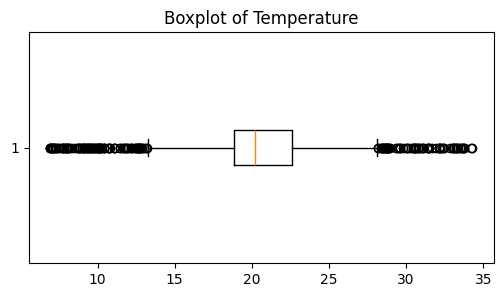

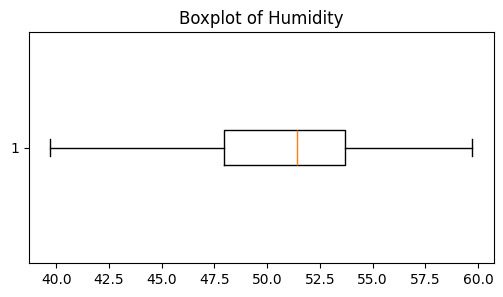

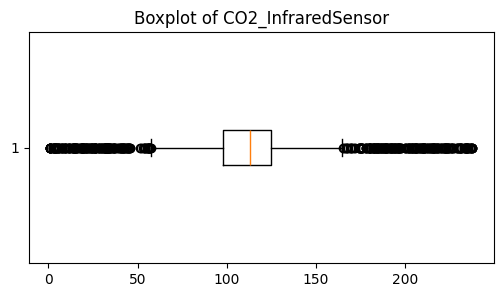

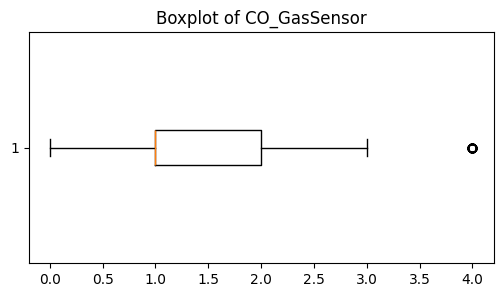

In [103]:
# Numerical columns for outlier detection
outlier_cols = [
    "Temperature",
    "Humidity",
    "CO2_InfraredSensor",
    "CO_GasSensor"
]

# Create boxplots
for col in outlier_cols:
    plt.figure(figsize=(6, 3))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.show()

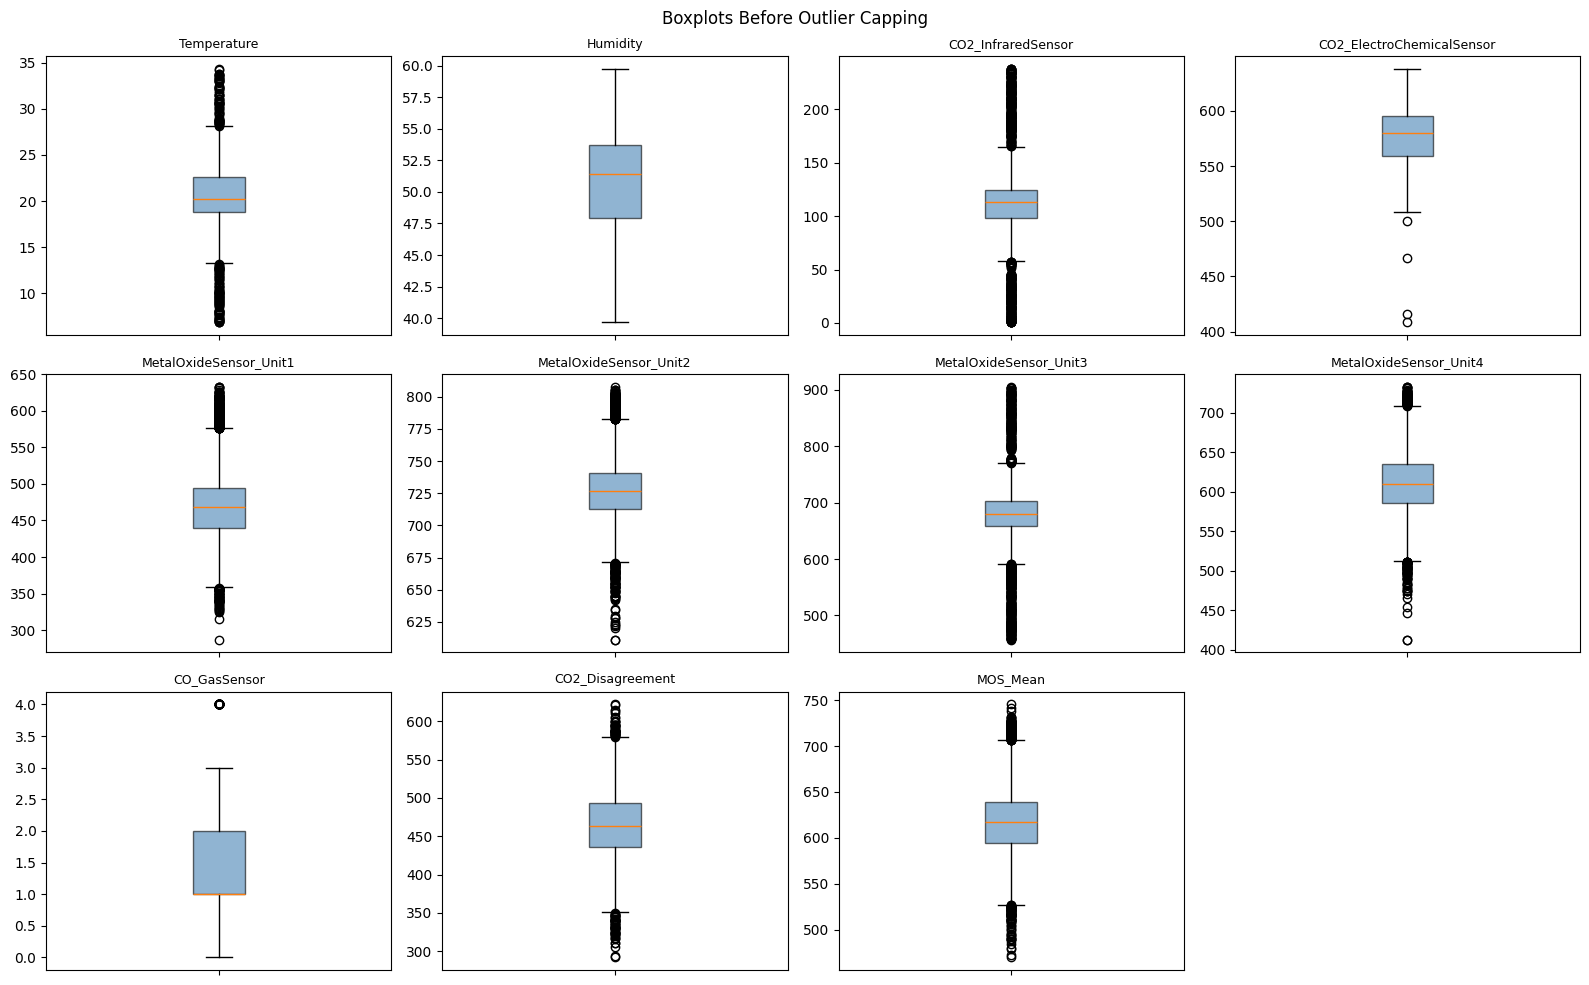

In [104]:
# Visualise outliers with boxplots before capping

# Columns to check for statistical outliers (copied from a later cell for self-containment)
outlier_columns = [
    "Temperature", "Humidity", "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor", "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2", "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4", "CO_GasSensor",
    "CO2_Disagreement", "MOS_Mean"
]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(outlier_columns):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor="steelblue", alpha=0.6))
    axes[i].set_title(col, fontsize=9)
    axes[i].tick_params(axis="x", labelbottom=False)

for j in range(len(outlier_columns), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Boxplots Before Outlier Capping", fontsize=12)
plt.tight_layout()
plt.show()

In [105]:
# Columns to check for statistical outliers
# We skip encoded/flag columns (Is_Night, Activity_Encoded, Ambient_Light_Ordinal)
outlier_columns = [
    "Temperature", "Humidity", "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor", "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2", "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4", "CO_GasSensor",
    "CO2_Disagreement", "MOS_Mean"
]

# IQR method: flag values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR
outlier_report = {}
for col in outlier_columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {"lower": lower, "upper": upper, "outliers": n_out}

outlier_df = pd.DataFrame(outlier_report).T
print("Outlier summary (IQR method):")
print(outlier_df.to_string())

Outlier summary (IQR method):
                                lower       upper  outliers
Temperature                 13.255000   28.175000     164.0
Humidity                    39.335000   62.335000       0.0
CO2_InfraredSensor          57.528579  165.072159     466.0
CO2_ElectroChemicalSensor  504.914628  649.849591       4.0
MetalOxideSensor_Unit1     358.147086  575.792183     359.0
MetalOxideSensor_Unit2     671.212480  782.604762     372.0
MetalOxideSensor_Unit3     591.585710  770.931634     495.0
MetalOxideSensor_Unit4     512.170627  709.080846     202.0
CO_GasSensor                -0.500000    3.500000      48.0
CO2_Disagreement           350.022578  579.893496      93.0
MOS_Mean                   526.706675  706.784021     264.0


In [106]:
# Cap outliers using Winsorization (clip to IQR bounds)
# This keeps the row but pulls extreme values to the fence — no data is lost
for col in outlier_columns:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=lower, upper=upper)

print("Outlier capping complete.")
print(f"Shape after capping: {df.shape}")
print(f"Missing values after capping: {df.isnull().sum().sum()}")

Outlier capping complete.
Shape after capping: (6159, 19)
Missing values after capping: 0


Purpose: To identify and reduce the influence of extreme sensor readings that may negatively affect scaling and machine learning performance.

Extreme sensor values were capped using IQR boundaries instead of removing rows. This approach reduces the impact of unusually large or small readings while preserving the overall dataset structure

# **7. Encode Categorical Features**



In [107]:
# Identify categorical columns
categorical_cols = [
    "Time of Day",
    "HVAC Operation Mode",
    "Activity Level"
]

print("Categorical Features:")
print(categorical_cols)

Categorical Features:
['Time of Day', 'HVAC Operation Mode', 'Activity Level']


To identify categorical features that require numerical encoding before machine learning.

In [108]:
# Apply one hot encoding
df = pd.get_dummies(
    df,
    columns=categorical_cols,
    drop_first=True
)

print("Encoding complete.")
print(f"Updated dataset shape: {df.shape}")

Encoding complete.
Updated dataset shape: (6159, 26)


To convert categorical labels into numerical format while avoiding ordinal assumptions between categories.

Categorical features were transformed into numerical representations using one hot encoding to ensure compatibility with machine learning algorithms. The first category was dropped during encoding to reduce redundancy and prevent multicollinearity between encoded variables.

# **8. Scale Numerical Features**

In [109]:
# Columns to scale only continuous sensor readings
# Exclude: encoded flags (0/1), ordinal columns, Session ID
scale_cols = [
    "Temperature", "Humidity", "CO2_InfraredSensor",
    "CO2_ElectroChemicalSensor", "MetalOxideSensor_Unit1",
    "MetalOxideSensor_Unit2", "MetalOxideSensor_Unit3",
    "MetalOxideSensor_Unit4", "CO_GasSensor",
    "CO2_Disagreement", "MOS_Mean"
]

# Fit and transform
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

# Verify: scaled columns should have mean ≈ 0 and std ≈ 1
print("Post-scaling stats (should be mean≈0, std≈1):")
print(df_scaled[scale_cols].agg(["mean", "std"]).round(4).to_string())

Post-scaling stats (should be mean≈0, std≈1):
      Temperature  Humidity  CO2_InfraredSensor  CO2_ElectroChemicalSensor  MetalOxideSensor_Unit1  MetalOxideSensor_Unit2  MetalOxideSensor_Unit3  MetalOxideSensor_Unit4  CO_GasSensor  CO2_Disagreement  MOS_Mean
mean      -0.0000    0.0000             -0.0000                    -0.0000                 -0.0000                 -0.0000                 -0.0000                 -0.0000        0.0000            0.0000    0.0000
std        1.0001    1.0001              1.0001                     1.0001                  1.0001                  1.0001                  1.0001                  1.0001        1.0001            1.0001    1.0001


In [110]:
# Keep both: df (unscaled, interpretable) and df_scaled (ready for modelling)
# For tree-based models (Random Forest, XGBoost) scaling is not needed
# For distance/gradient-based models (KNN, SVM, LogReg) use df_scaled
print(f"df        — original scale, shape: {df.shape}")
print(f"df_scaled — standardised,    shape: {df_scaled.shape}")

df        — original scale, shape: (6159, 26)
df_scaled — standardised,    shape: (6159, 26)


To standardize continuous sensor features so that variables with larger numerical ranges do not dominate machine learning models.

Continuous sensor features were standardized using StandardScaler while preserving a separate unscaled version of the dataset for interpretation. Scaling is particularly important for distance based and gradient based machine learning algorithms, while tree based models typically do not require feature scaling.